##  Visualizing coefficients on map

In [1]:
state='MA'
meas='TOBS'

### Load the required libraries

In [2]:
!ls lib

MultiPlot.py		 decomposer.py	    row_parser.py
Reconstruction_plots.py  getFiles.py	    sparkConfig.py
YearPlotter.py		 import_modules.py  spark_PCA.py
__init__.py		 leaflet.py	    spark_PCA_HW.py
__pycache__		 lib.tgz	    start_spark_context.py
binary_search.py	 numpy_pack.py	    startup.py
computeStatistics.py	 old


In [3]:
import warnings  # Suppress Warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2 

# sc.setLogLevel("ERROR")

_figsize=(10,7)

In [4]:
import matplotlib

In [5]:
import pandas as pd
import numpy as np
import sklearn as sk
import urllib
import math

from pickle import dump,load


In [6]:
%%time
%run lib/startup.py S

sc_type= S
10.46.173.20
namespace= grader-cse255-01
driver_host= 10.46.173.20


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


25/05/02 00:40:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
sparkContext= <SparkContext master=spark://spark-master-0.spark-headless.grader-cse255-01.svc.cluster.local:7077 appName=myapp>

version of ipwidgets= 8.1.6
parquet_root= /home/grader-cse255-01/public/Data/weather


measurements is a Dataframe (and table) with 12720632 records
stations is a Dataframe (and table) with 119503 records


weather is a Dataframe (and table) which is a join of measurements and stations with 12720632 records
CPU times: user 591 ms, sys: 169 ms, total: 760 ms
Wall time: 1min 5s


In [7]:
import warnings  # Suppress Warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2 

_figsize=(10,7)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
presentWD = !pwd
ns = presentWD[0].split('/')[2]
parquet_root=f'/home/{ns}/public/Data/weather'

ms=['TMAX', 'SNOW', 'SNWD', 'TMIN', 'PRCP', 'TOBS']
# ms=['TMAX', 'TMIN', 'TOBS']
cms='or\n'.join(['Measurement="%s" '%(m) for m in ms])

In [9]:

pkl_filename=parquet_root+'/weather-statistics/'+state+'-'+','.join(ms)+'.pkl'
!ls $pkl_filename 

../../../Data/weather/weather-statistics/MA-TMAX,SNOW,SNWD,TMIN,PRCP,TOBS.pkl


In [10]:
%%time
ms=[meas]
cms='or\n'.join(['Measurement="%s" '%(m) for m in ms])

##  read all data for state
Query="""
SELECT *
FROM weather
WHERE state="%s" and  measurement='%s'
"""%(state,meas)
print(Query)

weather_df=sqlContext.sql(Query).cache() #weather_df contains the information for the state
print('number of rows in result=',weather_df.count())
weather_df.show(1)


SELECT *
FROM weather
WHERE state="MA" and  measurement='TOBS'



number of rows in result= 4251
+-----------+-----------+----+--------------------+--------+---------+---------+----------+-------+-----+-------------+
|    Station|Measurement|Year|              Values|latitude|longitude|elevation|dist2coast|   name|state|      country|
+-----------+-----------+----+--------------------+--------+---------+---------+----------+-------+-----+-------------+
|USC00190120|       TOBS|2022|[4E 00 43 00 D9 F...| 42.3861| -72.5375|     44.2|   112.625|AMHERST|   MA|United States|
+-----------+-----------+----+--------------------+--------+---------+---------+----------+-------+-----+-------------+
only showing top 1 row

CPU times: user 41.2 ms, sys: 19.5 ms, total: 60.7 ms
Wall time: 40.5 s


In [11]:
import lib.numpy_pack
from lib.computeStatistics import load_or_compute_statistics
stat=load_or_compute_statistics(sc,sqlContext,pkl_filename,weather_df,ms)
STAT=stat
STAT.keys()

precomputed statistics file exists


dict_keys(['TMAX', 'SNOW', 'SNWD', 'TMIN', 'PRCP', 'TOBS'])

### compute spectral decomposition

In [12]:
%%time
#get mean and eigenvectors for measurement m
EigVec=STAT[meas]['eigvec']
Mean=STAT[meas]['Mean']
EigVec.shape

CPU times: user 18 µs, sys: 18 µs, total: 36 µs
Wall time: 38.9 µs


(366, 366)

In [13]:
%%time
import os

from lib.decomposer import decompose_dataframe
decomp_parquet=parquet_root+'weather-statistics/'+state+'-'+meas+'.parquet'
if os.path.isdir(decomp_parquet):
    print('reading',decomp_parquet)
    decomposition=sqlContext.read.parquet(decomp_parquet)
    print('number of rows=',decomposition.count())
else:
    print('Computing',decomp_parquet)
    sc.addPyFile("lib/decomposer.py")
    from decomposer import decompose_dataframe
    k=5
    decomposition= decompose_dataframe(sc,sqlContext,weather_df,EigVec[:,:k],Mean).cache() # Make it possible to generate only first k coefficients.
    print('number of rows=',decomposition.count())
    print('saving to',decomp_parquet)
    decomposition.write.parquet(decomp_parquet)

Computing ../../../Data/weatherweather-statistics/MA-TOBS.parquet


number of rows= 4251
saving to ../../../Data/weatherweather-statistics/MA-TOBS.parquet


CPU times: user 63.2 ms, sys: 47.4 ms, total: 111 ms
Wall time: 9.9 s


In [14]:
','.join(decomposition.columns)

'Station,Measurement,Year,Values,latitude,longitude,elevation,dist2coast,name,state,country,total_var,res_mean,res_1,coeff_1,res_2,coeff_2,res_3,coeff_3,res_4,coeff_4,res_5,coeff_5'

## Compute the count and average of `coeff_i` for each station.

In [15]:
feature='coeff_2'
df1 = decomposition.select('station','latitude','longitude','elevation','dist2coast',feature)
df1.show(2)

+-----------+--------+---------+---------+----------+------------------+
|    station|latitude|longitude|elevation|dist2coast|           coeff_2|
+-----------+--------+---------+---------+----------+------------------+
|USC00190120| 42.3861| -72.5375|     44.2|   112.625|-1.386384023748644|
|USC00190190| 42.6178| -71.9158|    337.7|   74.4375|-7.500269013832893|
+-----------+--------+---------+---------+----------+------------------+
only showing top 2 rows



In [16]:
df2=df1.groupby(['station','latitude','longitude','elevation','dist2coast'])\
.agg({"station": "count", feature: "mean"})
#df2=df1.groupby(['station']).agg({"station": "count", feature: "mean"})
pdf=df2.toPandas()
pdf.sort_values(by=['station'],inplace=True)
pdf.head(5)

,station,latitude,longitude,elevation,dist2coast,count(station),avg(coeff_2)
87,USC00190049,42.6500,-73.1000,228.9,151.750000,49,-8.233651
37,USC00190120,42.3861,-72.5375,44.2,112.625000,72,-8.222853
149,USC00190166,42.4167,-71.1833,54.9,11.351562,8,-6.572783
58,USC00190190,42.6178,-71.9158,337.7,74.437500,29,-2.972989
44,USC00190192,42.6617,-71.9358,349.3,79.187500,20,-2.322925


In [17]:
# Find long/lat bounding box
max_long=pdf['longitude'].max()
min_long=pdf['longitude'].min()
max_lat=pdf['latitude'].max()
min_lat=pdf['latitude'].min()
min_lat, max_lat, min_long,max_long


(41.2919, 42.8319, -73.45, -69.95)

Latitude:
from 41.2° N (south, near Martha's Vineyard)
to 42.9° N (north, near the New Hampshire border)

Longitude:
from 69.9° W (east, off Cape Cod)
to 73.5° W (west, near the New York border)

In [18]:
#define a mapping from the range of the value to hex colors.
from matplotlib.colors import rgb2hex
_avg='avg(%s)'%feature
_min=pdf[_avg].min()
_max=pdf[_avg].max()
_min,_max

(-32.227689077831876, 29.892569638986576)

In [19]:
import pylab as plt
cmap=plt.get_cmap('jet')
def get_color(val):
    x=(val-_min)/(_max-_min)
    return(rgb2hex(cmap(x)[:3]))

## Map
* Each circle is centered at a station.  
* The area of the circle corresponds to the number of years SNWD was recorded at the station.  
* The color fill of the circle corresponds to the value of `avg(coeff_1)` defined by color-bar.

### Folium

Folium is a package for annotating and viewing data on maps

In [20]:
1+1

2

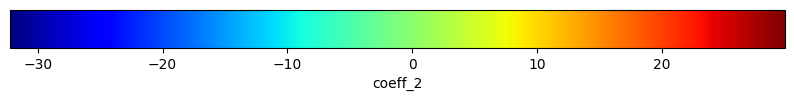

In [21]:
import folium
import numpy as np
import matplotlib.pyplot as plt

# --- Generate the color bar (rough equivalent) ---
def create_colorbar(_min, _max, cmap=plt.cm.jet):
    fig, ax = plt.subplots(figsize=(10, 1))
    fig.subplots_adjust(bottom=0.5)

    norm = plt.Normalize(vmin=_min, vmax=_max)
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                 cax=ax, orientation='horizontal', label=feature)
    plt.show()

# Example: call create_colorbar(_min, _max)
# (Folium can't embed matplotlib colorbars directly into map without plugins.)

# --- Create the map ---
center = [(min_lat + max_lat) / 2, (min_long + max_long) / 2]
zoom = 8

map = folium.Map(location=center, zoom_start=zoom, tiles='OpenTopoMap')

# --- Add rectangle ---
bounds = [[min_lat, min_long], [max_lat, max_long]]
folium.Rectangle(
    bounds=bounds,
    color='black',
    weight=5,
    fill_opacity=0.0
).add_to(map)


# --- Add circles ---
lat_margin = (max_lat - min_lat) / 4
long_margin = (max_long - min_long) / 4

for index, row in pdf.iterrows():
    _lat = row['latitude']
    _long = row['longitude']
    _count = row['count(station)']
    _coef = row[_avg]  # assuming _avg is the name of the column for coefficients

    radius = 1200 * np.sqrt(_count)  # radius in meters, similar to your code

    folium.Circle(
        location=(_lat, _long),
        radius=radius,
        color='#F00',
        weight=1,
        fill=True,
        fill_opacity=0.4,
        opacity=0.8,
        fill_color=get_color(_coef)  # assuming you have get_color(_coef) defined
    ).add_to(map)

# --- Display the map ---
create_colorbar(_min,_max)
map

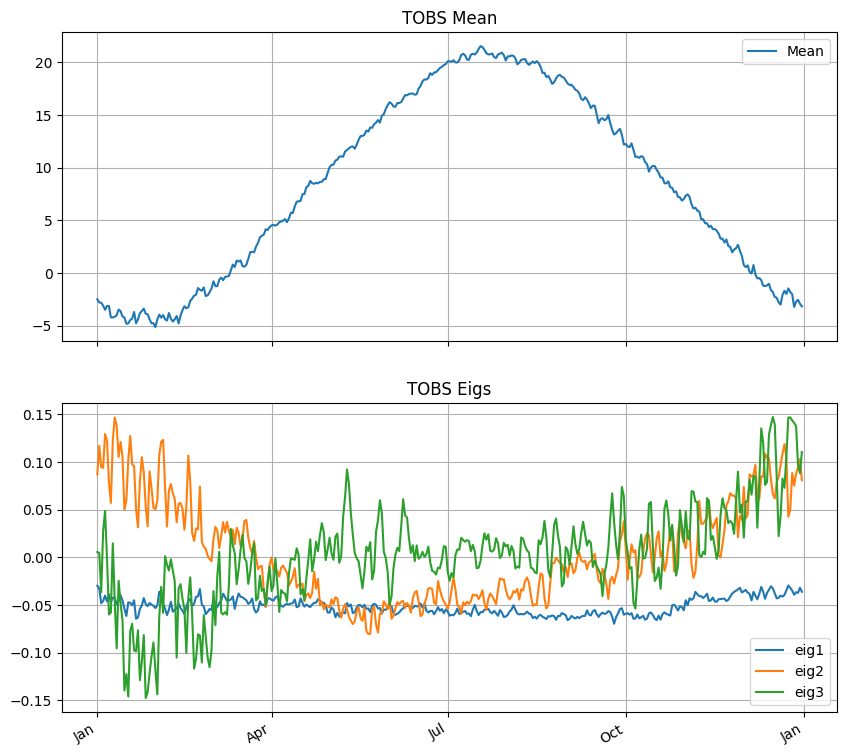

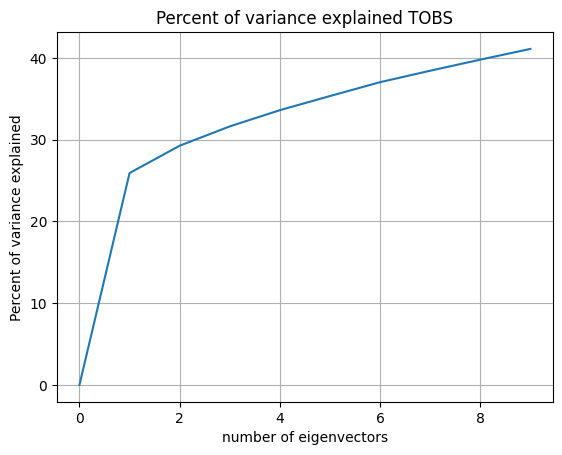

In [22]:
import pylab as plt
from lib.YearPlotter import YearPlotter

fig,axes=plt.subplots(2,1, sharex='col', sharey='row',figsize=(10,10));
k=3
EigVec=np.array(STAT[meas]['eigvec'][:,:k])
Mean=STAT[meas]['Mean']
YearPlotter().plot(Mean,fig,axes[0],label='Mean',title=meas+' Mean')
YearPlotter().plot(EigVec,fig,axes[1],title=meas+' Eigs',labels=['eig'+str(i+1) for i in range(k)])
fig,ax=plt.subplots(1,1);
eigvals=STAT[meas]['eigval']; eigvals/=sum(eigvals); cumvar=np.cumsum(eigvals); cumvar=100*np.insert(cumvar,0,0)
ax.plot(cumvar[:10]); 
ax.grid(); 
ax.set_ylabel('Percent of variance explained')
ax.set_xlabel('number of eigenvectors')
ax.set_title('Percent of variance explained '+meas);

### Is coef_x related to elevation ?

In [23]:
pdf

,station,latitude,longitude,elevation,dist2coast,count(station),avg(coeff_2)
87,USC00190049,42.6500,-73.1000,228.9,151.750000,49,-8.233651
37,USC00190120,42.3861,-72.5375,44.2,112.625000,72,-8.222853
149,USC00190166,42.4167,-71.1833,54.9,11.351562,8,-6.572783
58,USC00190190,42.6178,-71.9158,337.7,74.437500,29,-2.972989
44,USC00190192,42.6617,-71.9358,349.3,79.187500,20,-2.322925
...,...,...,...,...,...,...,...
38,USC00199972,42.3869,-72.9211,391.7,119.875000,27,1.622580
68,USW00014703,42.2000,-72.5333,75.0,97.312500,23,-8.633774
70,USW00014763,42.4272,-73.2892,363.9,128.500000,7,-6.885231
97,USW00054768,42.6958,-73.1708,199.3,157.000000,3,-0.600179


(0.0, 700.0)

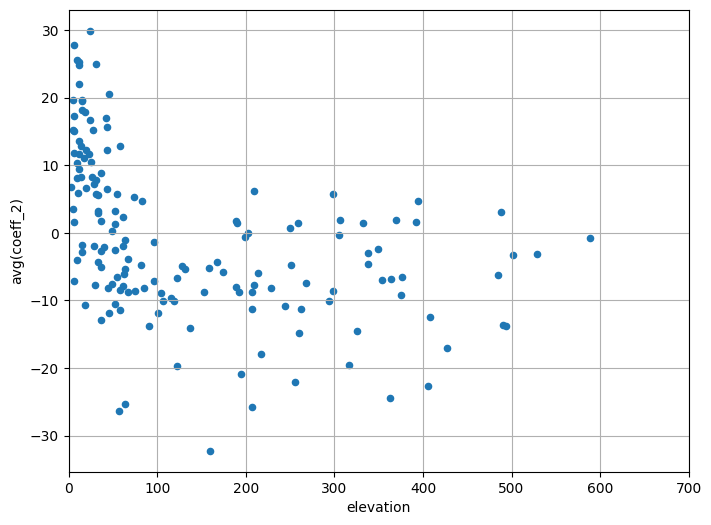

In [24]:
pdf.plot.scatter(x='elevation',y='avg(%s)'%feature,figsize=(8,6));
plt.grid()
plt.xlim([0,700])

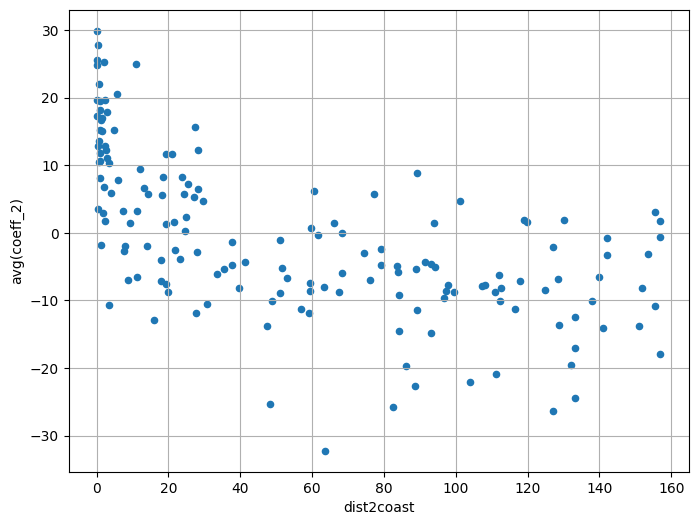

In [25]:
pdf.plot.scatter(x='dist2coast',y='avg(%s)'%feature,figsize=(8,6));
plt.grid()
#plt.xlim([0,1000])

(-50.0, 700.0)

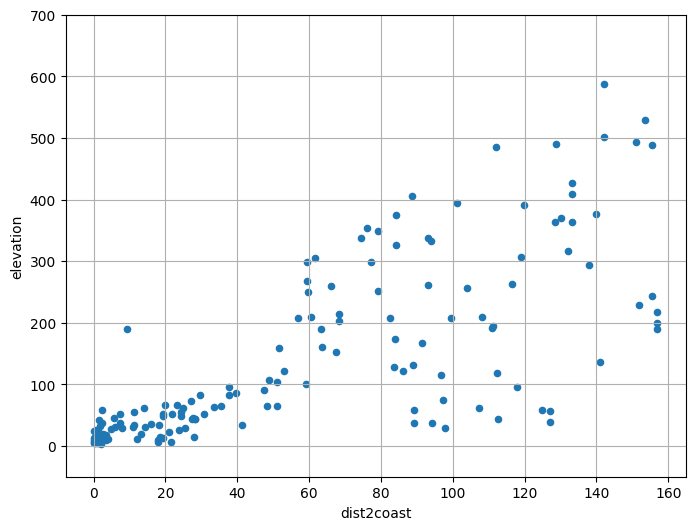

In [26]:
pdf.plot.scatter(x='dist2coast',y='elevation',figsize=(8,6));
plt.grid()
plt.ylim([-50,700])

## Summary
* We saw how to use `folium` to present data on top of maps.
* We saw that in MA most of the snow accumulation is in the Adirondacks.
* Snow accumulation increases with elevation, but the relationship is weak: locations with elevation 400-600 meters have widely varying accumulations of snow.